# Hyperparameter Tuning — Market Regime-Aware Stock Classification

Tunes LR, RF, and LightGBM for both Stage 1 (regime classification) and Stage 2 (stock-level Buy/Hold/Sell).
Uses **Optuna** for efficient Bayesian search with **TimeSeriesSplit** to preserve chronological integrity.

Outputs: best params saved to `results/best_params.json`, retrained models saved to `models/tuned/`

In [1]:
!pip install optuna --quiet

In [2]:
import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('lightgbm').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial noise

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)
N_TRIALS = 25   # Optuna trials per model — increase for better results, decrease for speed
N_CV_SPLITS = 3 # TimeSeriesSplit folds inside each Optuna trial

os.makedirs('results', exist_ok=True)
os.makedirs('models/tuned', exist_ok=True)
os.makedirs('plots/tuning', exist_ok=True)

print('Setup complete.')
print(f'Optuna version: {optuna.__version__}')

Setup complete.
Optuna version: 4.7.0


In [3]:
df = pd.read_csv('data/features/sp500_panel_with_features.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Encoded_Ticker', 'Date']).reset_index(drop=True)

S1_FEATURES = ['Ret_Lag1', 'Ret_Lag2', 'RSI', 'MACD_Norm',
               'ATR_Pct', 'HL_range', 'Price_vs_SMA50',
               'Momentum_Deviation', 'BB_Pct']

S2_FEATURES_BASE = ['Ret_Lag1', 'Ret_Lag2', 'RSI', 'MACD_Norm',
                    'ATR_Pct', 'HL_range', 'Price_vs_SMA50',
                    'Momentum_Deviation', 'BB_Pct', 'Encoded_Ticker']

S2_FEATURES_REGIME = S2_FEATURES_BASE + ['regime_pred']

print(f'Loaded: {len(df):,} rows | {df["Encoded_Ticker"].nunique()} tickers')

Loaded: 1,193,500 rows | 499 tickers


In [4]:
# ── Reconstruct Stage 1 market proxy + regime labels ──
WINDOW = 20
market_daily = (
    df.groupby('Date')['Ret_Lag1']
    .mean()
    .reset_index()
    .rename(columns={'Ret_Lag1': 'market_return'})
    .sort_values('Date')
)
market_daily['rolling_ret'] = market_daily['market_return'].rolling(WINDOW).mean()
market_daily['rolling_vol'] = market_daily['market_return'].rolling(WINDOW).std()
market_daily.dropna(inplace=True)

ret_hi = market_daily['rolling_ret'].quantile(0.60)
ret_lo = market_daily['rolling_ret'].quantile(0.40)
vol_hi = market_daily['rolling_vol'].quantile(0.70)

def assign_regime(row):
    if row['rolling_vol'] >= vol_hi: return 2
    elif row['rolling_ret'] >= ret_hi: return 0
    elif row['rolling_ret'] <= ret_lo: return 1
    else: return 0

market_daily['regime'] = market_daily.apply(assign_regime, axis=1)

stage1_df = (
    df.groupby('Date')[S1_FEATURES]
    .mean()
    .reset_index()
    .sort_values('Date')
    .merge(market_daily[['Date', 'regime']], on='Date', how='inner')
    .dropna()
    .reset_index(drop=True)
)

print(f'Stage 1 dataset: {stage1_df.shape}')

Stage 1 dataset: (2442, 11)


In [5]:
# ── Stage 1 train/test split ──
split_date_s1 = stage1_df['Date'].quantile(0.8)
train_s1 = stage1_df[stage1_df['Date'] <= split_date_s1]
test_s1  = stage1_df[stage1_df['Date'] >  split_date_s1]

scaler_s1 = StandardScaler()
X_train_s1 = scaler_s1.fit_transform(train_s1[S1_FEATURES].values)
X_test_s1  = scaler_s1.transform(test_s1[S1_FEATURES].values)
y_train_s1 = train_s1['regime'].values
y_test_s1  = test_s1['regime'].values

print(f'S1 Train: {X_train_s1.shape} | Test: {X_test_s1.shape}')

S1 Train: (1953, 9) | Test: (489, 9)


In [6]:
# ── Reconstruct Stage 2 signal labels + regime_pred ──
def label_signal(series):
    low  = series.quantile(0.33)
    high = series.quantile(0.67)
    if low == high:
        median = series.median()
        return pd.Series(
            np.where(series < median, 0, np.where(series > median, 2, 1)),
            index=series.index
        )
    return pd.cut(series, bins=[-np.inf, low, high, np.inf], labels=[0, 1, 2])

df['signal'] = df.groupby('Encoded_Ticker')['y_return'].transform(label_signal).astype(int)

# Load best Stage 1 model from ModelTraining to generate regime_pred
with open('models/lgb_s1.pkl', 'rb') as f:
    lgb_s1 = pickle.load(f)

X_all_s1_sc = scaler_s1.transform(stage1_df[S1_FEATURES].values)
stage1_df['regime_pred'] = lgb_s1.predict(X_all_s1_sc)

df = df.merge(stage1_df[['Date', 'regime_pred']], on='Date', how='left')
df['regime_pred'] = df['regime_pred'].ffill().bfill().astype(int)

print(f'regime_pred null count: {df["regime_pred"].isnull().sum()}')

regime_pred null count: 0


In [7]:
# ── Stage 2 train/test split ──
df_s2 = df[S2_FEATURES_REGIME + ['Date', 'signal']].dropna().sort_values('Date').reset_index(drop=True)

split_date_s2 = df_s2['Date'].quantile(0.8)
train_s2 = df_s2[df_s2['Date'] <= split_date_s2]
test_s2  = df_s2[df_s2['Date'] >  split_date_s2]

scaler_s2 = StandardScaler()
X_train_s2 = scaler_s2.fit_transform(train_s2[S2_FEATURES_REGIME].values)
X_test_s2  = scaler_s2.transform(test_s2[S2_FEATURES_REGIME].values)
y_train_s2 = train_s2['signal'].values
y_test_s2  = test_s2['signal'].values

print(f'S2 Train: {X_train_s2.shape} | Test: {X_test_s2.shape}')

S2 Train: (954991, 11) | Test: (238509, 11)


---
## 2. Tuning Utility
Single scorer used across all Optuna objectives — Macro F1 with TimeSeriesSplit.

In [8]:
import warnings
from sklearn.exceptions import DataConversionWarning

def ts_cv_score(model, X, y, n_splits=N_CV_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='X does not have valid feature names')
        scores = cross_val_score(model, X, y, cv=tscv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()


def plot_optuna_history(study, title, path):
    trials_df = study.trials_dataframe()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(trials_df['number'], trials_df['value'], alpha=0.4, color='steelblue', label='Trial F1')
    running_best = trials_df['value'].cummax()
    axes[0].plot(trials_df['number'], running_best, color='orange', lw=2, label='Best so far')
    axes[0].set_xlabel('Trial')
    axes[0].set_ylabel('Macro F1')
    axes[0].set_title(f'{title} — Optimization History')
    axes[0].legend()

    axes[1].hist(trials_df['value'].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[1].axvline(study.best_value, color='orange', lw=2, linestyle='--',
                    label=f'Best = {study.best_value:.4f}')
    axes[1].set_xlabel('Macro F1')
    axes[1].set_title(f'{title} — Score Distribution')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

print('Utility functions ready.')

Utility functions ready.


---
## 3. Stage 1 Tuning — Regime Classifier

### 3A. Logistic Regression

  0%|          | 0/25 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best LR S1 Macro F1: 0.7459
Best params: {'C': 0.13280825906303814, 'solver': 'lbfgs'}


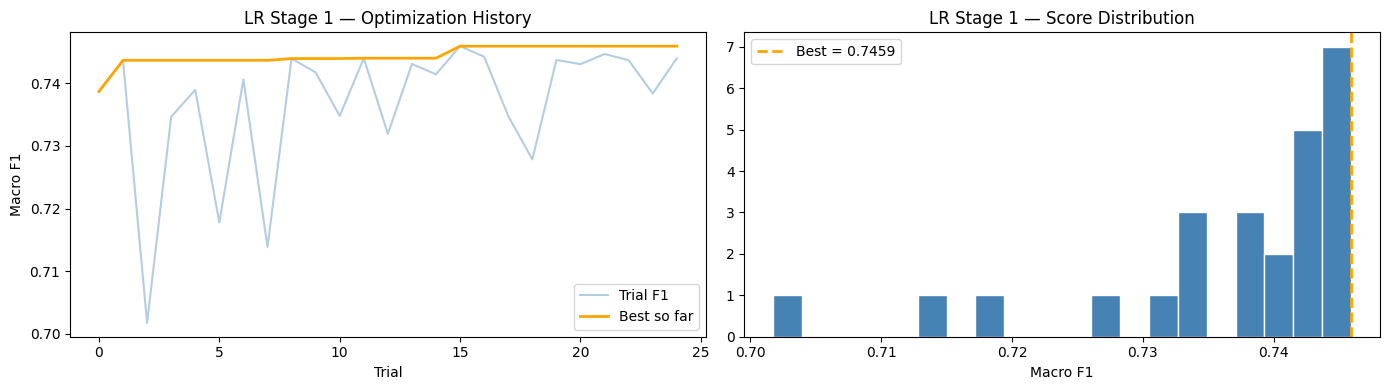

In [9]:
def objective_lr_s1(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'max_iter': 2000,
        'class_weight': 'balanced',
        'random_state': SEED,
    }
    model = LogisticRegression(**params)
    return ts_cv_score(model, X_train_s1, y_train_s1)

study_lr_s1 = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=SEED))
study_lr_s1.optimize(objective_lr_s1, n_trials=N_TRIALS, show_progress_bar=True)

print(f'Best LR S1 Macro F1: {study_lr_s1.best_value:.4f}')
print(f'Best params: {study_lr_s1.best_params}')
plot_optuna_history(study_lr_s1, 'LR Stage 1', 'plots/tuning/lr_s1.png')

### 3B. Random Forest

  0%|          | 0/25 [00:00<?, ?it/s]

Best RF S1 Macro F1: 0.7694
Best params: {'n_estimators': 429, 'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 16, 'max_features': 'sqrt'}


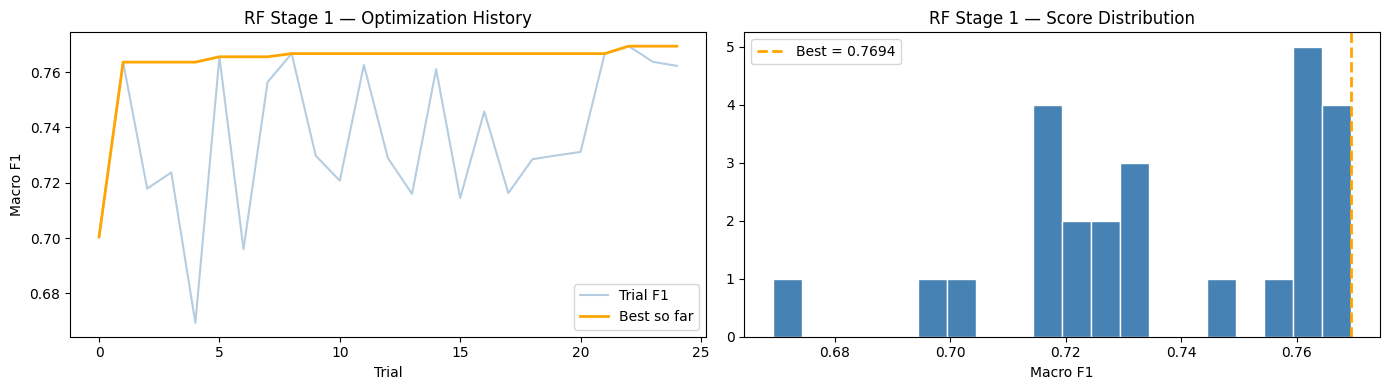

In [10]:
def objective_rf_s1(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8]),
        'class_weight': 'balanced',
        'random_state': SEED,
        'n_jobs': -1,
    }
    model = RandomForestClassifier(**params)
    return ts_cv_score(model, X_train_s1, y_train_s1)

study_rf_s1 = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=SEED))
study_rf_s1.optimize(objective_rf_s1, n_trials=N_TRIALS, show_progress_bar=True)

print(f'Best RF S1 Macro F1: {study_rf_s1.best_value:.4f}')
print(f'Best params: {study_rf_s1.best_params}')
plot_optuna_history(study_rf_s1, 'RF Stage 1', 'plots/tuning/rf_s1.png')

### 3C. LightGBM

  0%|          | 0/25 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

Best LGB S1 Macro F1: 0.7702
Best params: {'n_estimators': 114, 'learning_rate': 0.11041930924484174, 'max_depth': 5, 'num_leaves': 120, 'min_child_samples': 99, 'colsample_bytree': 0.8451235367845726, 'subsample': 0.628963476300746, 'reg_alpha': 0.00011077902520957406, 'reg_lambda': 0.75379333134501}


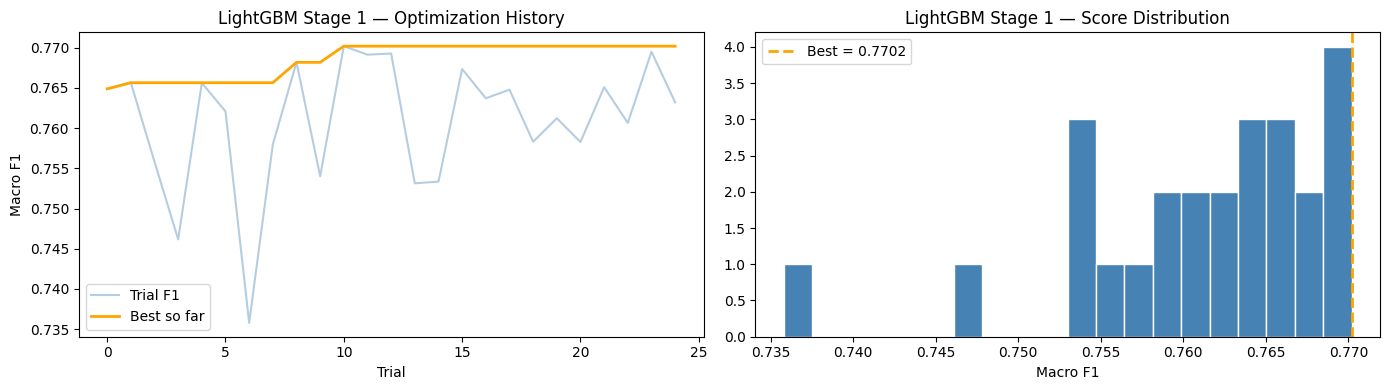

In [11]:
from sklearn.exceptions import DataConversionWarning

def objective_lgb_s1(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'class_weight': 'balanced',
        'random_state': SEED,
        'n_jobs': -1,
        'verbose': -1,
    }
    model = lgb.LGBMClassifier(**params)
    return ts_cv_score(model, X_train_s1, y_train_s1)

study_lgb_s1 = optuna.create_study(direction='maximize',
                                        sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb_s1.optimize(objective_lgb_s1, n_trials=N_TRIALS, show_progress_bar=True)
    
print(f'Best LGB S1 Macro F1: {study_lgb_s1.best_value:.4f}')
print(f'Best params: {study_lgb_s1.best_params}')
plot_optuna_history(study_lgb_s1, 'LightGBM Stage 1', 'plots/tuning/lgb_s1.png')

### 3D. Retrain Stage 1 with Best Params & Evaluate

In [12]:
REGIME_NAMES = {0: 'Bullish', 1: 'Bearish', 2: 'High-Volatility'}

# Retrain on full training set with tuned params
best_lr_s1 = LogisticRegression(
    **study_lr_s1.best_params,
    max_iter=2000, class_weight='balanced', random_state=SEED
)
best_lr_s1.fit(X_train_s1, y_train_s1)

best_rf_s1 = RandomForestClassifier(
    **study_rf_s1.best_params,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
best_rf_s1.fit(X_train_s1, y_train_s1)

best_lgb_s1 = lgb.LGBMClassifier(
    **study_lgb_s1.best_params,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)
best_lgb_s1.fit(X_train_s1, y_train_s1)

s1_tuned_results = {
    'Logistic Regression': (y_test_s1, best_lr_s1.predict(X_test_s1)),
    'Random Forest': (y_test_s1, best_rf_s1.predict(X_test_s1)),
    'LightGBM': (y_test_s1, best_lgb_s1.predict(X_test_s1)),
}

print('=== Stage 1 — Tuned Model Results ===')
for name, (yt, yp) in s1_tuned_results.items():
    print(f'\n--- {name} ---')
    print(classification_report(yt, yp, target_names=list(REGIME_NAMES.values())))

=== Stage 1 — Tuned Model Results ===

--- Logistic Regression ---
                 precision    recall  f1-score   support

        Bullish       0.80      0.65      0.72       248
        Bearish       0.78      0.53      0.63       162
High-Volatility       0.31      0.71      0.44        79

       accuracy                           0.62       489
      macro avg       0.63      0.63      0.60       489
   weighted avg       0.72      0.62      0.64       489


--- Random Forest ---
                 precision    recall  f1-score   support

        Bullish       0.80      0.69      0.74       248
        Bearish       0.76      0.57      0.65       162
High-Volatility       0.38      0.72      0.50        79

       accuracy                           0.66       489
      macro avg       0.64      0.66      0.63       489
   weighted avg       0.72      0.66      0.67       489


--- LightGBM ---
                 precision    recall  f1-score   support

        Bullish       0.80    

In [13]:
# ── Before vs After comparison table ──
# Baseline results from ModelTraining (hardcoded from your saved CSVs)
baseline_s1 = {
    'Logistic Regression': 0.6041,
    'Random Forest': 0.6315,
    'LightGBM': 0.6690,
}

comparison_s1 = pd.DataFrame([
    {
        'Model': name,
        'Baseline Macro F1': baseline_s1[name],
        'Tuned Macro F1': f1_score(yt, yp, average='macro'),
        'Delta': f1_score(yt, yp, average='macro') - baseline_s1[name],
    }
    for name, (yt, yp) in s1_tuned_results.items()
])

print('=== Stage 1 — Tuning Impact ===')
print(comparison_s1.to_string(index=False))

=== Stage 1 — Tuning Impact ===
              Model  Baseline Macro F1  Tuned Macro F1     Delta
Logistic Regression             0.6041        0.595100 -0.009000
      Random Forest             0.6315        0.630421 -0.001079
           LightGBM             0.6690        0.658137 -0.010863


---
## 4. Update Stage 2 with Tuned Stage 1 Regime Predictions
Re-generate `regime_pred` using the best tuned Stage 1 model before tuning Stage 2.

In [14]:
# Pick best tuned S1 model by Macro F1
best_s1_name = comparison_s1.loc[comparison_s1['Tuned Macro F1'].idxmax(), 'Model']
best_s1_model = {'Logistic Regression': best_lr_s1,
                 'Random Forest': best_rf_s1,
                 'LightGBM': best_lgb_s1}[best_s1_name]

print(f'Best Stage 1 model: {best_s1_name}')

X_all_s1_sc = scaler_s1.transform(stage1_df[S1_FEATURES].values)
stage1_df['regime_pred'] = best_s1_model.predict(X_all_s1_sc)

# Drop old regime_pred from df and re-merge
if 'regime_pred' in df.columns:
    df.drop(columns=['regime_pred'], inplace=True)

df = df.merge(stage1_df[['Date', 'regime_pred']], on='Date', how='left')
df['regime_pred'] = df['regime_pred'].ffill().bfill().astype(int)

# Rebuild Stage 2 splits with updated regime_pred
df_s2 = df[S2_FEATURES_REGIME + ['Date', 'signal']].dropna().sort_values('Date').reset_index(drop=True)
split_date_s2 = df_s2['Date'].quantile(0.8)
train_s2 = df_s2[df_s2['Date'] <= split_date_s2]
test_s2  = df_s2[df_s2['Date'] >  split_date_s2]

scaler_s2 = StandardScaler()
X_train_s2 = scaler_s2.fit_transform(train_s2[S2_FEATURES_REGIME].values)
X_test_s2  = scaler_s2.transform(test_s2[S2_FEATURES_REGIME].values)
y_train_s2 = train_s2['signal'].values
y_test_s2  = test_s2['signal'].values

print(f'Stage 2 rebuilt with tuned regime_pred. Train: {X_train_s2.shape}')

Best Stage 1 model: LightGBM
Stage 2 rebuilt with tuned regime_pred. Train: (954991, 11)


---
## 5. Stage 2 Tuning — Stock-Level Classifier

### 5A. Logistic Regression

  0%|          | 0/25 [00:00<?, ?it/s]

Best LR S2 Macro F1: 0.3615
Best params: {'C': 0.29889419748420054, 'solver': 'lbfgs'}


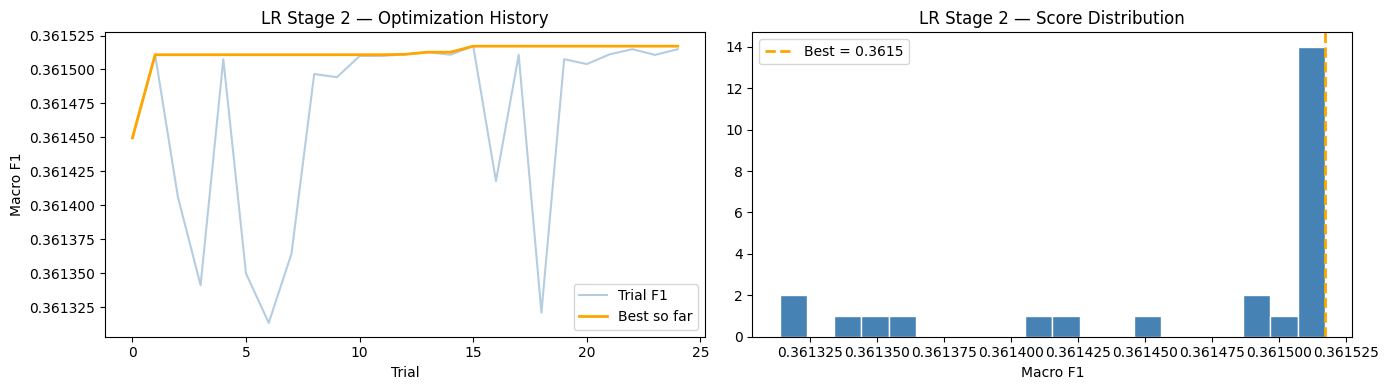

In [15]:
def objective_lr_s2(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'max_iter': 2000,
        'class_weight': 'balanced',
        'random_state': SEED,
    }
    model = LogisticRegression(**params)
    return ts_cv_score(model, X_train_s2, y_train_s2)

study_lr_s2 = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=SEED))
study_lr_s2.optimize(objective_lr_s2, n_trials=N_TRIALS, show_progress_bar=True)

print(f'Best LR S2 Macro F1: {study_lr_s2.best_value:.4f}')
print(f'Best params: {study_lr_s2.best_params}')
plot_optuna_history(study_lr_s2, 'LR Stage 2', 'plots/tuning/lr_s2.png')

### 5B. Random Forest

  0%|          | 0/25 [00:00<?, ?it/s]

Best RF S2 Macro F1: 0.3873
Best params: {'n_estimators': 92, 'max_depth': 10, 'min_samples_leaf': 113, 'min_samples_split': 171, 'max_features': 'log2'}


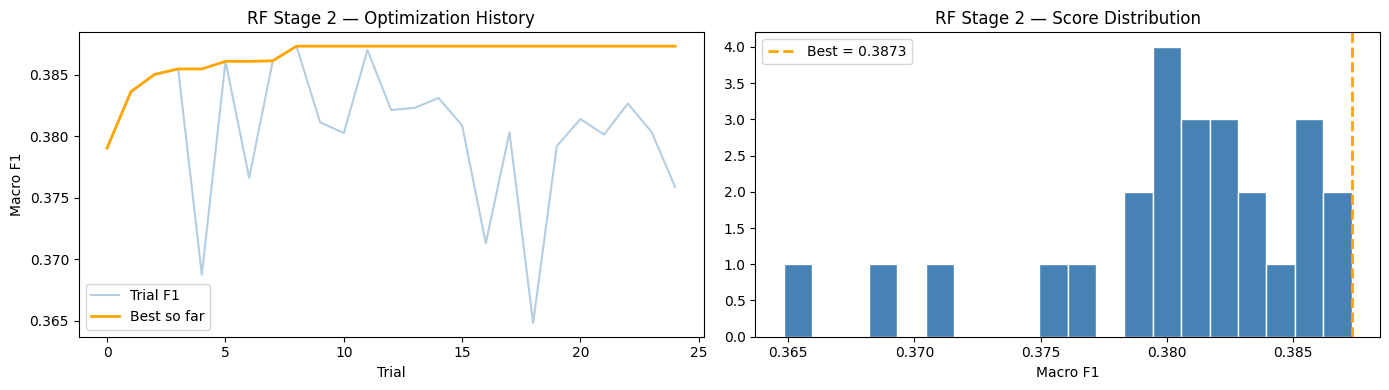

In [16]:
def objective_rf_s2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 4, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 50, 500),
        'min_samples_split': trial.suggest_int('min_samples_split', 50, 200),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8]),
        'class_weight': 'balanced_subsample',
        'random_state': SEED,
        'n_jobs': -1,
    }
    model = RandomForestClassifier(**params)
    idx = np.random.choice(len(X_train_s2), size=50000, replace=False)
    return ts_cv_score(model, X_train_s2[idx], y_train_s2[idx])

study_rf_s2 = optuna.create_study(direction='maximize',
                                   sampler=optuna.samplers.TPESampler(seed=SEED))
study_rf_s2.optimize(objective_rf_s2, n_trials=N_TRIALS, show_progress_bar=True)

print(f'Best RF S2 Macro F1: {study_rf_s2.best_value:.4f}')
print(f'Best params: {study_rf_s2.best_params}')
plot_optuna_history(study_rf_s2, 'RF Stage 2', 'plots/tuning/rf_s2.png')

### 5C. LightGBM

  0%|          | 0/25 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

Best LGB S2 Macro F1: 0.3660
Best params: {'n_estimators': 740, 'learning_rate': 0.010072618403206937, 'max_depth': 5, 'num_leaves': 255, 'min_child_samples': 172, 'colsample_bytree': 0.8899802540983397, 'subsample': 0.9855355977976394, 'subsample_freq': 1, 'reg_alpha': 0.803308109032679, 'reg_lambda': 2.5007462926228303}


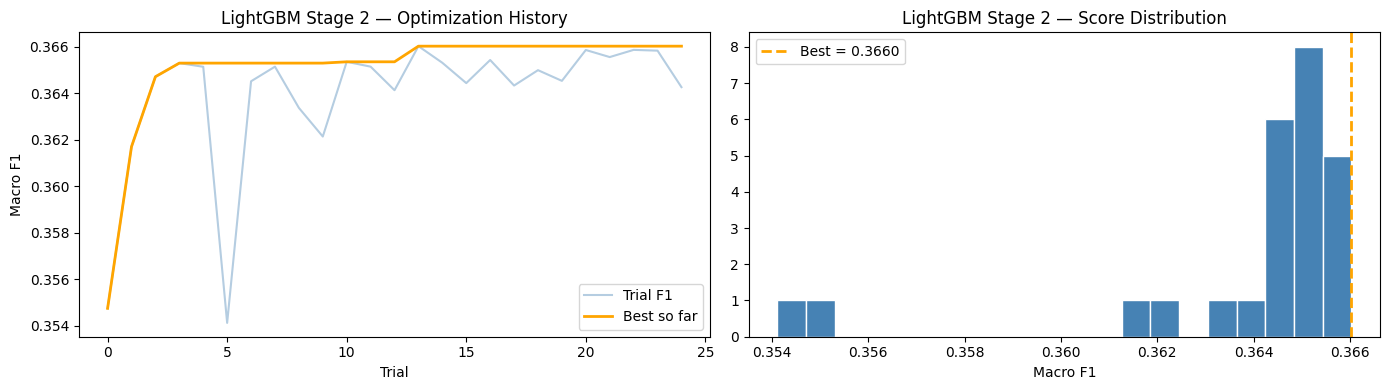

In [17]:
def objective_lgb_s2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': SEED,
        'n_jobs': -1,
        'verbose': -1,
    }
    model = lgb.LGBMClassifier(**params)
    return ts_cv_score(model, X_train_s2, y_train_s2)

study_lgb_s2 = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb_s2.optimize(objective_lgb_s2, n_trials=N_TRIALS, show_progress_bar=True)

print(f'Best LGB S2 Macro F1: {study_lgb_s2.best_value:.4f}')
print(f'Best params: {study_lgb_s2.best_params}')
plot_optuna_history(study_lgb_s2, 'LightGBM Stage 2', 'plots/tuning/lgb_s2.png')

### 5D. Retrain Stage 2 with Best Params & Evaluate

In [18]:
SIGNAL_NAMES = {0: 'Sell', 1: 'Hold', 2: 'Buy'}

best_lr_s2 = LogisticRegression(
    **study_lr_s2.best_params,
    max_iter=2000, class_weight='balanced', random_state=SEED
)
best_lr_s2.fit(X_train_s2, y_train_s2)

best_rf_s2 = RandomForestClassifier(
    **study_rf_s2.best_params,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
best_rf_s2.fit(X_train_s2, y_train_s2)

best_lgb_s2 = lgb.LGBMClassifier(
    **study_lgb_s2.best_params,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
)
best_lgb_s2.fit(X_train_s2, y_train_s2)

s2_tuned_results = {
    'Logistic Regression': (y_test_s2, best_lr_s2.predict(X_test_s2)),
    'Random Forest': (y_test_s2, best_rf_s2.predict(X_test_s2)),
    'LightGBM': (y_test_s2, best_lgb_s2.predict(X_test_s2)),
}

print('=== Stage 2 — Tuned Model Results ===')
for name, (yt, yp) in s2_tuned_results.items():
    print(f'\n--- {name} ---')
    print(classification_report(yt, yp, target_names=list(SIGNAL_NAMES.values())))

=== Stage 2 — Tuned Model Results ===

--- Logistic Regression ---
              precision    recall  f1-score   support

        Sell       0.34      0.14      0.20     79562
        Hold       0.37      0.55      0.44     80088
         Buy       0.36      0.38      0.37     78859

    accuracy                           0.36    238509
   macro avg       0.35      0.36      0.34    238509
weighted avg       0.35      0.36      0.34    238509


--- Random Forest ---
              precision    recall  f1-score   support

        Sell       0.35      0.20      0.26     79562
        Hold       0.37      0.54      0.44     80088
         Buy       0.36      0.34      0.35     78859

    accuracy                           0.36    238509
   macro avg       0.36      0.36      0.35    238509
weighted avg       0.36      0.36      0.35    238509


--- LightGBM ---
              precision    recall  f1-score   support

        Sell       0.35      0.21      0.26     79562
        Hold       0.

---
## 6. Final Comparison — Baseline vs Tuned

In [19]:
# Baseline Stage 2 results from ModelTraining CSVs
baseline_s2 = {
    'Logistic Regression': 0.3377,
    'Random Forest': 0.3491,
    'LightGBM': 0.3523,
}

comparison_s2 = pd.DataFrame([
    {
        'Model': name,
        'Baseline Macro F1': baseline_s2[name],
        'Tuned Macro F1': f1_score(yt, yp, average='macro'),
        'Delta': f1_score(yt, yp, average='macro') - baseline_s2[name],
    }
    for name, (yt, yp) in s2_tuned_results.items()
])

print('=== Stage 1 Tuning Impact ===')
print(comparison_s1.to_string(index=False))
print()
print('=== Stage 2 Tuning Impact ===')
print(comparison_s2.to_string(index=False))

=== Stage 1 Tuning Impact ===
              Model  Baseline Macro F1  Tuned Macro F1     Delta
Logistic Regression             0.6041        0.595100 -0.009000
      Random Forest             0.6315        0.630421 -0.001079
           LightGBM             0.6690        0.658137 -0.010863

=== Stage 2 Tuning Impact ===
              Model  Baseline Macro F1  Tuned Macro F1     Delta
Logistic Regression             0.3377        0.336104 -0.001596
      Random Forest             0.3491        0.349062 -0.000038
           LightGBM             0.3523        0.351635 -0.000665


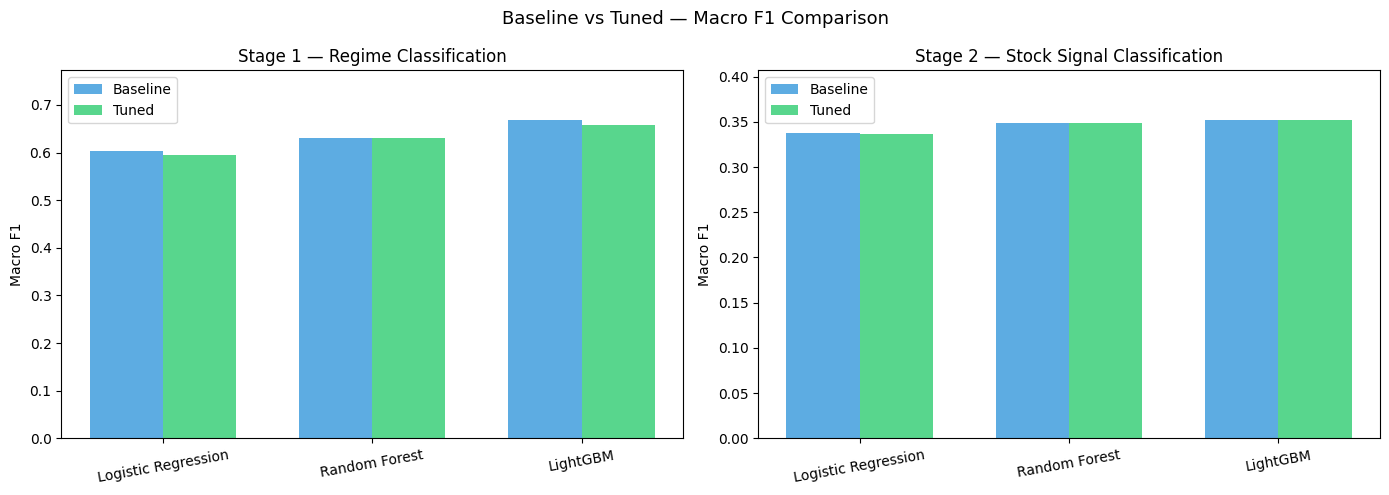

In [20]:
# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (comp_df, title) in zip(axes, [
    (comparison_s1, 'Stage 1 — Regime Classification'),
    (comparison_s2, 'Stage 2 — Stock Signal Classification')
]):
    x = np.arange(len(comp_df))
    w = 0.35
    ax.bar(x - w/2, comp_df['Baseline Macro F1'], w, label='Baseline', color='#3498db', alpha=0.8)
    ax.bar(x + w/2, comp_df['Tuned Macro F1'],    w, label='Tuned',    color='#2ecc71', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(comp_df['Model'], rotation=10)
    ax.set_ylabel('Macro F1')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.suptitle('Baseline vs Tuned — Macro F1 Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('plots/tuning/baseline_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

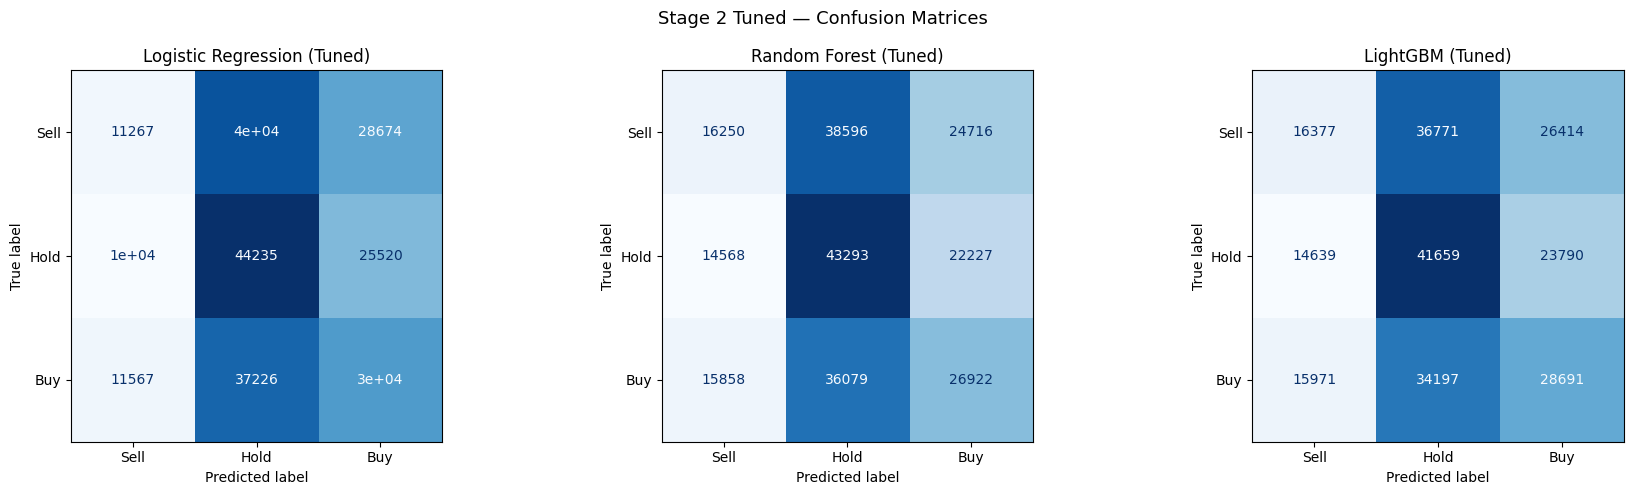

In [21]:
# ── Confusion matrices for tuned Stage 2 models ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (yt, yp)) in zip(axes, s2_tuned_results.items()):
    cm = confusion_matrix(yt, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=list(SIGNAL_NAMES.values()))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} (Tuned)')
plt.suptitle('Stage 2 Tuned — Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('plots/tuning/s2_tuned_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Save Everything

In [22]:
# Save tuned models
for name, model in [('lr_s1', best_lr_s1), ('rf_s1', best_rf_s1), ('lgb_s1', best_lgb_s1),
                    ('lr_s2', best_lr_s2), ('rf_s2', best_rf_s2), ('lgb_s2', best_lgb_s2)]:
    with open(f'models/tuned/{name}.pkl', 'wb') as f:
        pickle.dump(model, f)

# Save scalers
with open('models/tuned/scaler_s1.pkl', 'wb') as f: pickle.dump(scaler_s1, f)
with open('models/tuned/scaler_s2.pkl', 'wb') as f: pickle.dump(scaler_s2, f)

# Save best params as JSON
best_params = {
    'stage1': {
        'logistic_regression': study_lr_s1.best_params,
        'random_forest': study_rf_s1.best_params,
        'lightgbm': study_lgb_s1.best_params,
    },
    'stage2': {
        'logistic_regression': study_lr_s2.best_params,
        'random_forest': study_rf_s2.best_params,
        'lightgbm': study_lgb_s2.best_params,
    }
}
with open('results/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

# Save comparison tables
comparison_s1.to_csv('results/tuning_comparison_s1.csv', index=False)
comparison_s2.to_csv('results/tuning_comparison_s2.csv', index=False)

print('All tuned models, params, and results saved.')
print(json.dumps(best_params, indent=2))

All tuned models, params, and results saved.
{
  "stage1": {
    "logistic_regression": {
      "C": 0.13280825906303814,
      "solver": "lbfgs"
    },
    "random_forest": {
      "n_estimators": 429,
      "max_depth": 10,
      "min_samples_leaf": 8,
      "min_samples_split": 16,
      "max_features": "sqrt"
    },
    "lightgbm": {
      "n_estimators": 114,
      "learning_rate": 0.11041930924484174,
      "max_depth": 5,
      "num_leaves": 120,
      "min_child_samples": 99,
      "colsample_bytree": 0.8451235367845726,
      "subsample": 0.628963476300746,
      "reg_alpha": 0.00011077902520957406,
      "reg_lambda": 0.75379333134501
    }
  },
  "stage2": {
    "logistic_regression": {
      "C": 0.29889419748420054,
      "solver": "lbfgs"
    },
    "random_forest": {
      "n_estimators": 92,
      "max_depth": 10,
      "min_samples_leaf": 113,
      "min_samples_split": 171,
      "max_features": "log2"
    },
    "lightgbm": {
      "n_estimators": 740,
      "learnin